In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r"D:\Ultimate Programming\Data Bases\Project Dataset\Twitter\twitter_training.csv")
vla = pd.read_csv(r"D:\Ultimate Programming\Data Bases\Project Dataset\Twitter\twitter_validation.csv")
col = ['Tweet Id', 'Entity','Sentiment','Tweet Content']
data.columns = col
vla.columns = col

In [3]:
df = pd.concat([data, vla], ignore_index=True)

# Data Cleaning

In [4]:
df.shape

(75680, 4)

In [5]:
df.dropna(inplace=True)

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(2856)

In [8]:
df.drop_duplicates(inplace=True)
print(df.shape)

(72138, 4)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72138 entries, 0 to 75676
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet Id       72138 non-null  int64 
 1   Entity         72138 non-null  object
 2   Sentiment      72138 non-null  object
 3   Tweet Content  72138 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.8+ MB


# Exploratory Data Analysis (EDA)

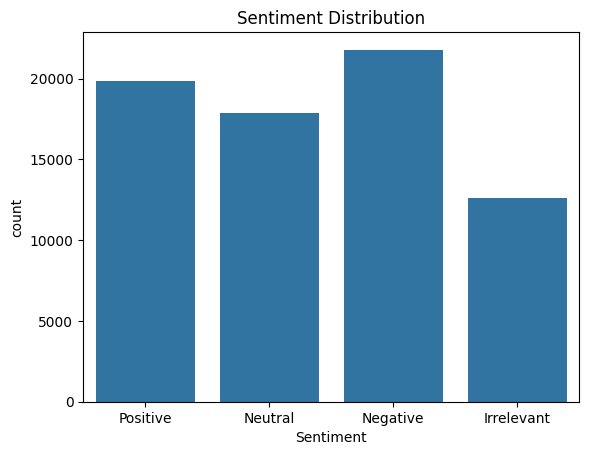

In [10]:
sns.countplot(data=df, x='Sentiment')
plt.title('Sentiment Distribution')
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Entity'] = le.fit_transform(df['Entity'])
df['Sentiment'] = le.fit_transform(df['Sentiment'])

In [12]:
df.head(2)

,Tweet Id,Entity,Sentiment,Tweet Content
0,2401,4,3,I am coming to the borders and I will kill you...
1,2401,4,3,im getting on borderlands and i will kill you ...


In [13]:
df['total_char'] = df['Tweet Content'].apply(len)

In [14]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')
df['total_word'] = df['Tweet Content'].apply(lambda x: len(nltk.word_tokenize(x)))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\iamaf\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\iamaf\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [15]:
df.head(2)

,Tweet Id,Entity,Sentiment,Tweet Content,total_char,total_word
0,2401,4,3,I am coming to the borders and I will kill you...,51,13
1,2401,4,3,im getting on borderlands and i will kill you ...,50,11


In [16]:
df['total_sentence'] = df['Tweet Content'].apply(lambda x: len(nltk.sent_tokenize(x)))

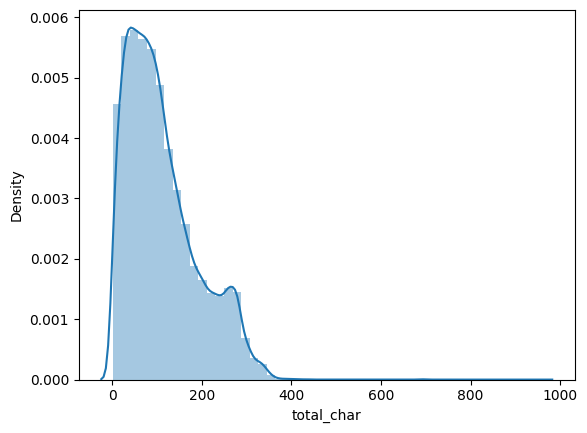

In [17]:
sns.distplot(df['total_char'])
plt.show()

In [18]:
q1 = df['total_char'].quantile(0.25)
q3 = df['total_char'].quantile(0.75)
iqr = q3 - q1
min_range = q1 - 1.5*iqr
max_range = q3 + 1.5*iqr
df = df[df['total_char']<max_range]

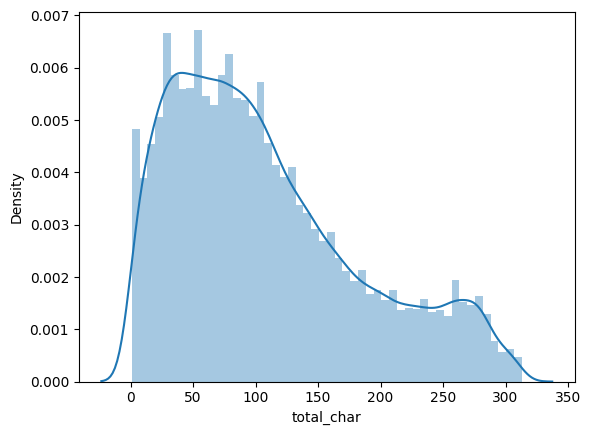

In [19]:
sns.distplot(df['total_char'])
plt.show()

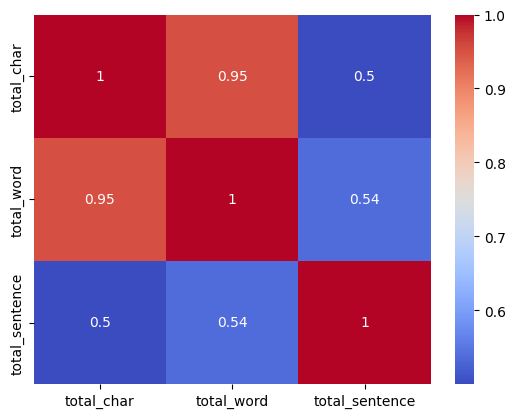

In [20]:
data = df[['total_char', 'total_word', 'total_sentence']]

sns.heatmap(data=data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [21]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\iamaf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [23]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [24]:
df['transformed_tweet'] = df['Tweet Content'].apply(transform_text)

In [25]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

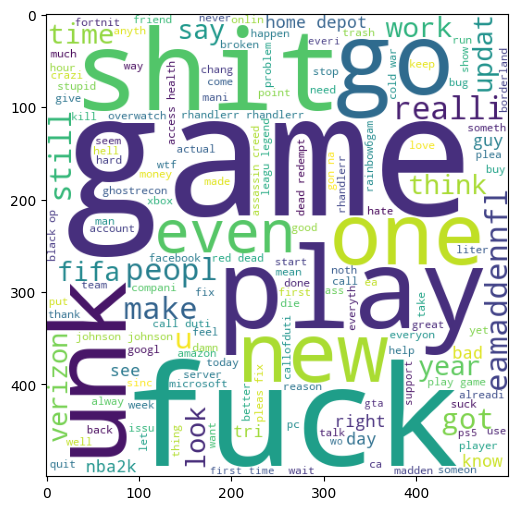

In [26]:
neg_wc = wc.generate(df[df['Sentiment'] == 1]['transformed_tweet'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(neg_wc)

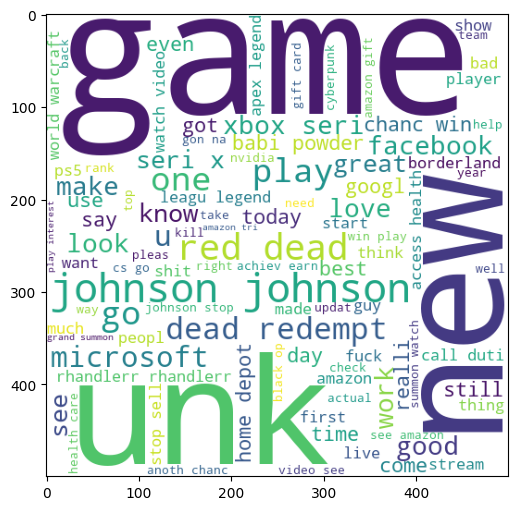

In [27]:
neutral_wc = wc.generate(df[df['Sentiment'] == 2]['transformed_tweet'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(neutral_wc)

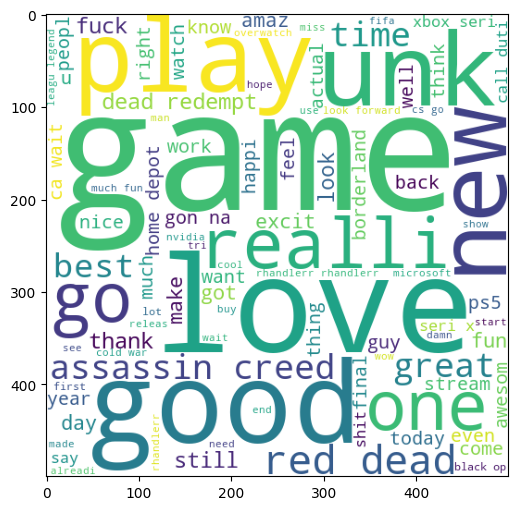

In [28]:
pos_wc = wc.generate(df[df['Sentiment'] == 3]['transformed_tweet'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(pos_wc)

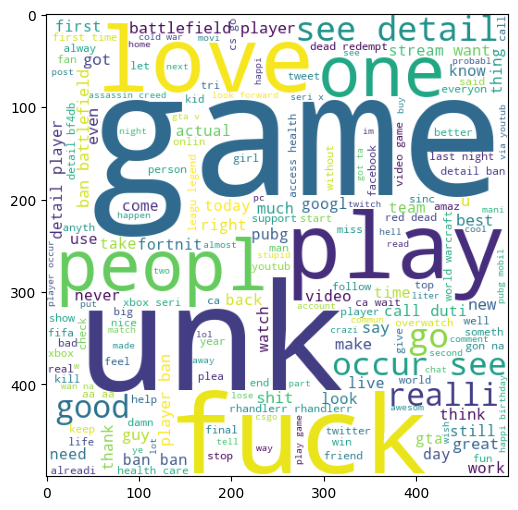

In [29]:
irr_wc = wc.generate(df[df['Sentiment'] == 0]['transformed_tweet'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(irr_wc)

# Model Building

In [30]:
df['Sentiment'].value_counts()

Sentiment
1    21522
3    19664
2    17662
0    12467
Name: count, dtype: int64

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000)
x = cv.fit_transform(df['transformed_tweet']).toarray()

In [32]:
y = df['Sentiment']

In [33]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [34]:
print(x.shape, " ", y.shape)

(71315, 5000)   (71315,)


In [35]:
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB

In [36]:
bn = BernoulliNB()
bn.fit(x_train, y_train)

BernoulliNB()

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score

In [38]:
lr = LogisticRegression()
mb = MultinomialNB()
gb = GaussianNB()
svm = SVC()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

In [39]:
model = {
    'lr' : lr,
    'mb' : mb,
    'gb' : gb,
    'svm' : svm,
    'dt' : dt,
    'rf' : rf
}

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

def train_classification(cls, x_train, x_test, y_train, y_test):
    cls.fit(x_train, y_train)
    y_pred = cls.predict(x_test)
    
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='macro') 
    f1 = f1_score(y_test, y_pred, average='macro') 
    
    return acc, recall, f1

for name, cls in model.items():
    acc, recall, f1 = train_classification(cls, x_train, x_test, y_train, y_test)
    print(f"For {name}: accuracy - {acc:.2f}, recall - {recall:.2f}, f1 - {f1:.2f}")
    print(f"For {name}: test - {cls.score(x_test, y_test)*100:.2f}%, train - {cls.score(x_train, y_train)*100:.2f}%")


For lr: accuracy - 0.70, recall - 0.69, f1 - 0.69
For lr: test - 69.95%, train - 77.25%
For mb: accuracy - 0.63, recall - 0.62, f1 - 0.62
For mb: test - 63.49%, train - 66.54%
For gb: accuracy - 0.42, recall - 0.47, f1 - 0.42
For gb: test - 41.83%, train - 44.56%
